In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

In [163]:
iris=load_iris()

In [164]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [165]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [166]:
df['target']=iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [167]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [168]:
df[df.target==0].head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [169]:
df[df.target==1].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1


In [170]:
df[df.target==2].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
100,6.3,3.3,6.0,2.5,2
101,5.8,2.7,5.1,1.9,2
102,7.1,3.0,5.9,2.1,2
103,6.3,2.9,5.6,1.8,2
104,6.5,3.0,5.8,2.2,2


In [171]:
df0=df[:50]
df1=df[50:100]
df2=df[100:]

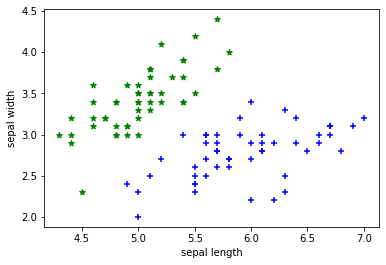

In [172]:
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.scatter(df0['sepal length (cm)'],df0['sepal width (cm)'],color="green",marker='*')
plt.scatter(df1['sepal length (cm)'],df1['sepal width (cm)'],color="blue",marker='+')

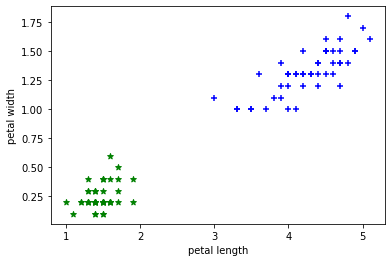

In [173]:
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.scatter(df0['petal length (cm)'],df0['petal width (cm)'],color="green",marker='*')
plt.scatter(df1['petal length (cm)'],df1['petal width (cm)'],color="blue",marker='+')

In [174]:
x=df.drop(['target'],axis='columns')

In [175]:
y=df.target

In [176]:
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [177]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int32

In [178]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [179]:
len(x_test)

30

In [180]:
len(x_train)

120

In [181]:
knn=KNeighborsClassifier(n_neighbors=3)

In [182]:
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [183]:
predicted=knn.predict(x_test)

In [184]:
predicted

array([0, 1, 2, 0, 2, 2, 0, 1, 1, 1, 1, 1, 2, 1, 0, 1, 0, 0, 2, 2, 1, 1,
       0, 2, 1, 2, 1, 1, 1, 2])

In [185]:
y_test

4      0
93     1
140    2
24     0
102    2
122    2
18     0
62     1
84     1
89     1
65     1
99     1
107    2
82     1
32     0
60     1
36     0
38     0
128    2
110    2
57     1
75     1
10     0
141    2
59     1
130    2
77     1
56     1
69     1
145    2
Name: target, dtype: int32

In [186]:
accuracy=accuracy_score(y_test,predicted)

In [187]:
accuracy

1.0

In [188]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,predicted)
cm

array([[ 7,  0,  0],
       [ 0, 14,  0],
       [ 0,  0,  9]], dtype=int64)

Text(42.0, 0.5, 'True')

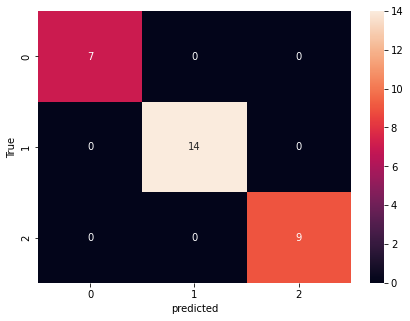

In [189]:
import seaborn as sn
plt.figure(figsize=(7,5))
sn.heatmap(cm,annot=True)
plt.xlabel('predicted')
plt.ylabel('True')

In [190]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         9

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [191]:
new_data=pd.DataFrame({"sepal length":[6.7],"sepal width":[6.5],"petal length":[3.4],"petal width":[2.9]})

In [192]:
new_data.columns=[
    'sepal length (cm)',
    'sepal width (cm)',
    'petal length (cm)',
    'petal width (cm)'
]
prediction=knn.predict(new_data)

In [193]:
prediction

array([1])